In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from src.risk.IRRBB_shocks import IRRBBShock
from src.risk.nii_engine import NIIEngine

In [2]:
# load portfolio cashflows
portfolio_cf = pd.read_csv('../data/processed/portfolio_cashflows.csv', index_col = 0)
display(portfolio_cf.head())

# load base yield curve
curve_raw = pd.read_csv('../data/processed/yield_curve_clean.csv')
display(curve_raw.head())

,date,principal,interest,total_cashflow,outstanding_balance,instrument_type
0,2026-03-01,750.657847,1175.000000,1925.657847,299249.342153,asset
1,2026-04-01,753.597923,1172.059923,1925.657847,298495.744230,asset
2,2026-05-01,756.549515,1169.108332,1925.657847,297739.194714,asset
3,2026-06-01,759.512668,1166.145179,1925.657847,296979.682047,asset
4,2026-07-01,762.487426,1163.170421,1925.657847,296217.194621,asset


,Date,1M,3M,6M,1Y,2Y,5Y,10Y,30Y
0,2001-07-31,0.0367,0.0354,0.0347,0.0353,0.0379,0.0457,0.0507,0.0551
1,2001-08-01,0.0365,0.0353,0.0347,0.0356,0.0383,0.0462,0.0511,0.0553
2,2001-08-02,0.0365,0.0353,0.0346,0.0357,0.0389,0.0469,0.0517,0.0557
3,2001-08-03,0.0363,0.0352,0.0347,0.0357,0.0391,0.0472,0.0520,0.0559
4,2001-08-06,0.0362,0.0352,0.0347,0.0356,0.0388,0.0471,0.0519,0.0559


In [3]:
# convert curve into long format
def prepare_curve_for_irrbb(
        curve_df: pd.DataFrame,
        valuation_date: datetime
) -> pd.DataFrame:
    """ 
    Select closest available curve before valuation date 
    and convert historical yield curve dataset into
    single curve into long format (tenor, rate)
    """
    
    curve_df['Date'] = pd.to_datetime(curve_df['Date'])

    # step 1: keep the curve dataset before valuation date
    curve_hist = curve_df.loc[
        curve_df['Date'] <= valuation_date
    ]

    if curve_hist.empty:
        raise ValueError("No curve available before valuation date!")
    
    # step 2: pick latest available curve before valuation date
    latest_curve = curve_hist.sort_values('Date').iloc[-1].copy()

    # step 3: drop date column
    latest_curve = latest_curve.drop('Date')

    # step 4: wide into long format
    curve_long = (
            latest_curve
            .rename_axis('tenor_label')
            .reset_index(name = 'rate')
    )

    tenor_map = {
        "1M": 1/12,
        "3M": 3/12,
        "6M": 6/12,
        "1Y": 1,
        "2Y": 2,
        "5Y": 5,
        "10Y": 10,
        "30Y": 30
    }

    curve_long['tenor'] = curve_long['tenor_label'].map(tenor_map)
    curve_long = curve_long.loc[:, ['tenor', 'rate']].sort_values('tenor')

    return curve_long

In [4]:
# initiating valuation datetime object
valuation_date = datetime(2026, 3, 1)

# converting curve into long format
curve = prepare_curve_for_irrbb(
    curve_df = curve_raw,
    valuation_date = valuation_date
)

# initiating IRRBB shock and NII engines
shock_engine = IRRBBShock(base_curve = curve)
nii_engine = NIIEngine(valuation_date = valuation_date)

# compute base nii
base_nii = nii_engine.compute_nii(
    portfolio_cf = portfolio_cf,
    curve = curve 
)
print(f"Base NII: {base_nii:.2f}")

Base NII: -501771.73


In [6]:
# compute NII under Basel shocks
scenarios = {
    'parallel_up': shock_engine.parallel_up(),
    'parallel_down': shock_engine.parallel_down(),
    'short_up': shock_engine.short_rate_up(),
    'short_down': shock_engine.short_rate_down(),
    'steepener': shock_engine.steepener(),
    'flattener': shock_engine.flattener()
}

results = {}
for name, shocked_curve in scenarios.items():
    
    nii = nii_engine.compute_nii(
        portfolio_cf = portfolio_cf,
        curve = shocked_curve
    )

    results[name] = nii - base_nii

results_df = pd.DataFrame.from_dict(
    results, 
    orient = 'index', 
    columns=['Delta_NII']
)

results_df

,Delta_NII
parallel_up,-288374.558998
parallel_down,288374.558998
short_up,-360468.198748
short_down,360468.198748
steepener,144187.279499
flattener,-144187.279499


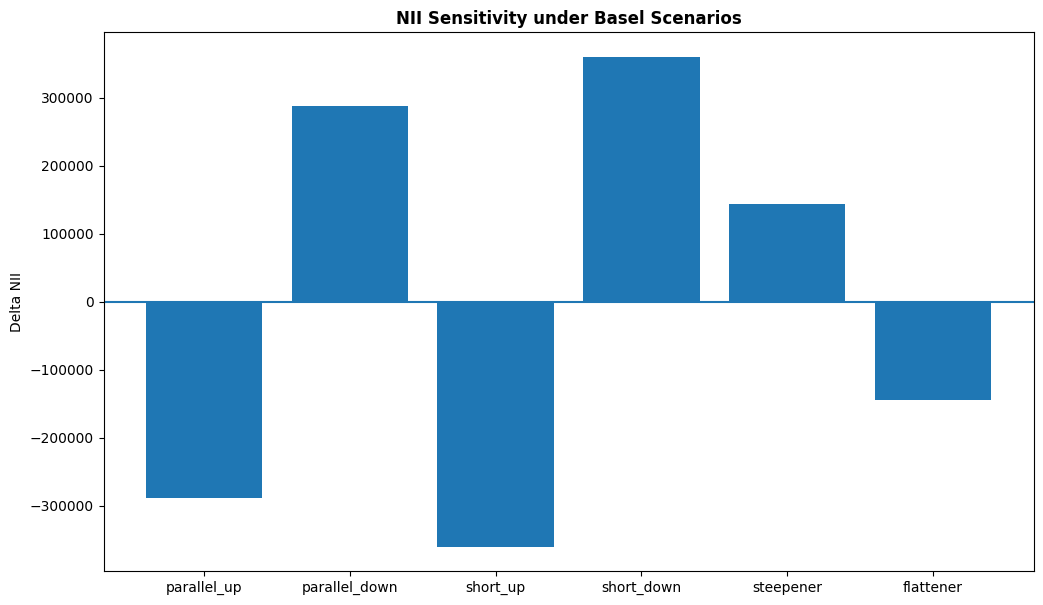

In [7]:
# plotting delta NII under Basel shock scenarios
plt.figure(figsize=(12, 7))
plt.bar(
    results_df.index,
    results_df['Delta_NII']
)
plt.axhline(0)
plt.title('NII Sensitivity under Basel Scenarios', fontweight = 'bold')
plt.ylabel('Delta NII')
plt.show()